# Decisão adaptativa de canais — Datathon MLET

## 1. Contexto do negócio

Uma instituição financeira precisa escolher entre contato por **cellular** ou **telephone** para cada oportunidade elegível. Comparamos a regra determinística `always_telephone` a Thompson Sampling contextual por segmentos, buscando aumentar recompensa/conversão acumulada com uma decisão explicável.

## 2. Fonte Kaggle

Base pública [`henriqueyamahata/bank-marketing`](https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing). A unidade é uma interação; `y` é normalizado para recompensa binária. Seed global: 42.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.bandits import ContextualThompsonSampling
from src.data import ARMS, load_bank_marketing, prepare_data, train_test_split
from src.evaluation import estimate_reward_probabilities

raw, dataset_path = load_bank_marketing(download_if_missing=True)
print(f"Arquivo: {dataset_path}")
print(f"Dimensão bruta: {raw.shape}")

Arquivo: C:\Users\lmaya\Downloads\datathon\data\raw\bank-additional-full.csv
Dimensão bruta: (41188, 21)


## 3–4. Carregamento, schema e qualidade

In [2]:
quality = pd.Series({
    "linhas": len(raw),
    "colunas": raw.shape[1],
    "duplicadas": int(raw.duplicated().sum()),
    "células_nulas": int(raw.isna().sum().sum()),
})
display(quality.to_frame("valor"))
display(pd.DataFrame({"dtype": raw.dtypes.astype(str), "nulos": raw.isna().sum()}).head(25))

,valor
linhas,41188
colunas,21
duplicadas,12
células_nulas,0


,dtype,nulos
age,int64,0
job,object,0
marital,object,0
education,object,0
default,object,0
housing,object,0
loan,object,0
contact,object,0
month,object,0
day_of_week,object,0


## 5–6. Limpeza e prevenção de leakage

In [3]:
prepared, cleaning = prepare_data(raw)
display(pd.Series(cleaning, name="resultado da limpeza").to_frame())
assert "duration" not in prepared.columns
print("`duration` foi removida: só é conhecida após o contato e causaria leakage.")

,resultado da limpeza
original_rows,41188
usable_rows,41188
unknown_or_unsupported_contact_rows_removed,0
invalid_required_rows_removed,0
duration_removed,True
target_source_column,y
arms,"[cellular, telephone]"
segments,6


`duration` foi removida: só é conhecida após o contato e causaria leakage.


## 7. Distribuição do target

,proporção
reward,
não converteu,0.887346
converteu,0.112654


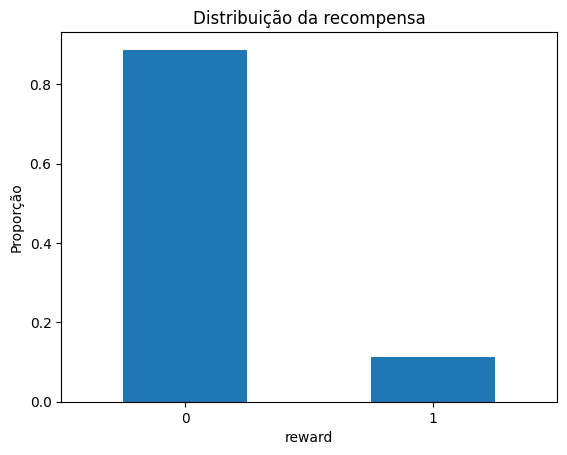

In [4]:
target_distribution = prepared["reward"].value_counts(normalize=True).sort_index()
display(target_distribution.rename(index={0: "não converteu", 1: "converteu"}).to_frame("proporção"))
target_distribution.plot.bar(title="Distribuição da recompensa", ylabel="Proporção", rot=0)
plt.show()

## 8. Conversão observada por canal

,count,mean
contact,,
cellular,26144,14.74%
telephone,15044,5.23%


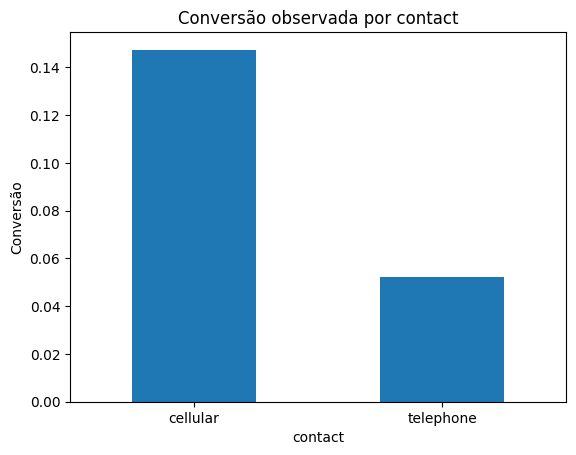

In [5]:
contact_summary = prepared.groupby("contact")["reward"].agg(["count", "mean"])
display(contact_summary.style.format({"mean": "{:.2%}"}))
contact_summary["mean"].plot.bar(title="Conversão observada por contact", ylabel="Conversão", rot=0)
plt.show()

## 9. Contexto: `poutcome`, `previous` e `campaign`

In [6]:
context_analysis = pd.DataFrame({
    "poutcome": prepared.groupby("poutcome")["reward"].mean(),
}).dropna()
display(context_analysis.style.format("{:.2%}"))
display(prepared.assign(previous_bucket=prepared["previous"].gt(0).map({False: "0", True: ">0"})).groupby("previous_bucket")["reward"].agg(["count", "mean"]))
display(prepared.assign(campaign_bucket=prepared["campaign"].le(2).map({True: "1-2", False: "3+"})).groupby("campaign_bucket")["reward"].agg(["count", "mean"]))

,poutcome
poutcome,
failure,14.23%
nonexistent/other,8.83%
success,65.11%


,count,mean
previous_bucket,,
0,35563,0.088322
>0,5625,0.266489


,count,mean
campaign_bucket,,
1-2,28212,0.124451
3+,12976,0.087007


## 10. Segmentação explicável

In [7]:
segment_summary = prepared.groupby("segment")["reward"].agg(["count", "mean"]).sort_values("mean", ascending=False)
display(segment_summary.style.format({"mean": "{:.2%}"}))

,count,mean
segment,,
poutcome=success|previous=gt0|campaign=1-2,1124,66.55%
poutcome=success|previous=gt0|campaign=3+,249,58.63%
poutcome=failure|previous=gt0|campaign=1-2,3307,14.45%
poutcome=failure|previous=gt0|campaign=3+,945,13.44%
poutcome=nonexistent/other|previous=0|campaign=1-2,23781,9.61%
poutcome=nonexistent/other|previous=0|campaign=3+,11782,7.27%


## 11. Baseline oficial — `always_telephone`

In [8]:
metrics = json.loads((PROJECT_ROOT / "artifacts" / "metrics.json").read_text(encoding="utf-8"))
print(f"Conversão simulada do baseline fixo: {metrics['baseline_fixed_conversion']:.3%}")

Conversão simulada do baseline fixo: 7.574%


## 12. Baseline adicional — melhor braço histórico global

In [9]:
print(f"Braço global: {metrics['baseline_best_arm']}")
print(f"Conversão simulada: {metrics['baseline_best_arm_conversion']:.3%}")

Braço global: cellular
Conversão simulada: 13.574%


## 13. Thompson Sampling contextual

In [10]:
train, test = train_test_split(prepared, seed=42)
bandit = ContextualThompsonSampling.warm_start(train, ARMS, seed=42)
probabilities, global_probabilities = estimate_reward_probabilities(train, ARMS)
print("Prior Beta(1,1); warm-start: alpha=1+sucessos e beta=1+falhas.")
display(pd.DataFrame({arm: {"posterior_mean_global": bandit.posterior_mean("segmento_novo", arm)} for arm in ARMS}).T)

Prior Beta(1,1); warm-start: alpha=1+sucessos e beta=1+falhas.


,posterior_mean_global
cellular,0.145100
telephone,0.050974


## 14. Metodologia da simulação offline

As probabilidades `P(reward=1 | segmento, braço)` são estimadas **somente no treino** com suavização Beta/Laplace. Os contextos do teste são repetidos até 50 mil interações e uma matriz de recompensas potenciais é pré-gerada com seed 42. Todas as políticas usam essa mesma matriz; o oráculo escolhe a maior probabilidade estimada e existe apenas para o cálculo de regret.

Esta é uma simulação contrafactual calibrada em dados observacionais — **não é avaliação causal**. Só um experimento controlado/A-B pode estimar efeito em produção.

## 15. Métricas comparativas

In [11]:
comparison = pd.DataFrame({
    "política": ["always_telephone", "global_best_historical", "contextual_thompson_sampling"],
    "conversão": [metrics["baseline_fixed_conversion"], metrics["baseline_best_arm_conversion"], metrics["adaptive_conversion"]],
    "recompensa acumulada": [metrics["baseline_fixed_cumulative_reward"], metrics["baseline_best_arm_cumulative_reward"], metrics["adaptive_cumulative_reward"]],
})
display(comparison.style.format({"conversão": "{:.3%}"}))
print(f"Lift absoluto: {metrics['lift_absolute']:.3%}")
print(f"Lift relativo: {metrics['lift_percent']:.2f}%")
print(f"Pseudo-regret acumulado: {metrics['cumulative_regret']:.3f}")

,política,conversão,recompensa acumulada
0,always_telephone,7.574%,3787
1,global_best_historical,13.574%,6787
2,contextual_thompson_sampling,13.764%,6882


Lift absoluto: 6.190%
Lift relativo: 81.73%
Pseudo-regret acumulado: 18.456


## 16. Gráficos gerados

conversion_comparison.png


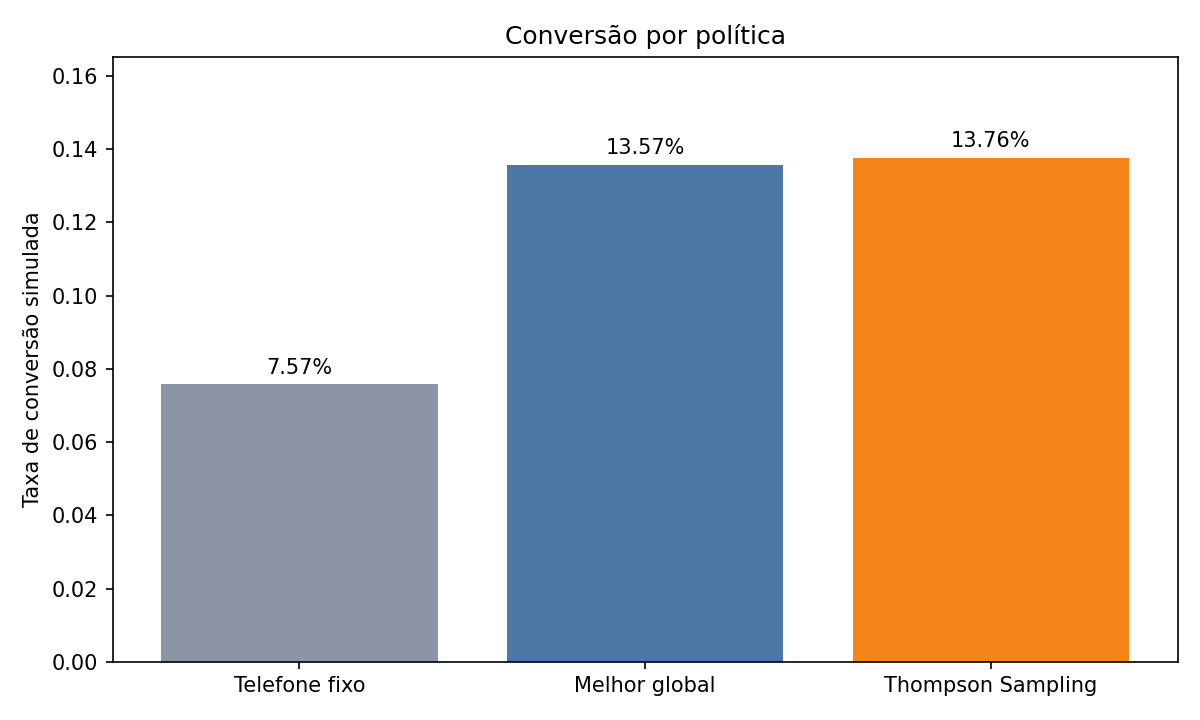

cumulative_reward.png


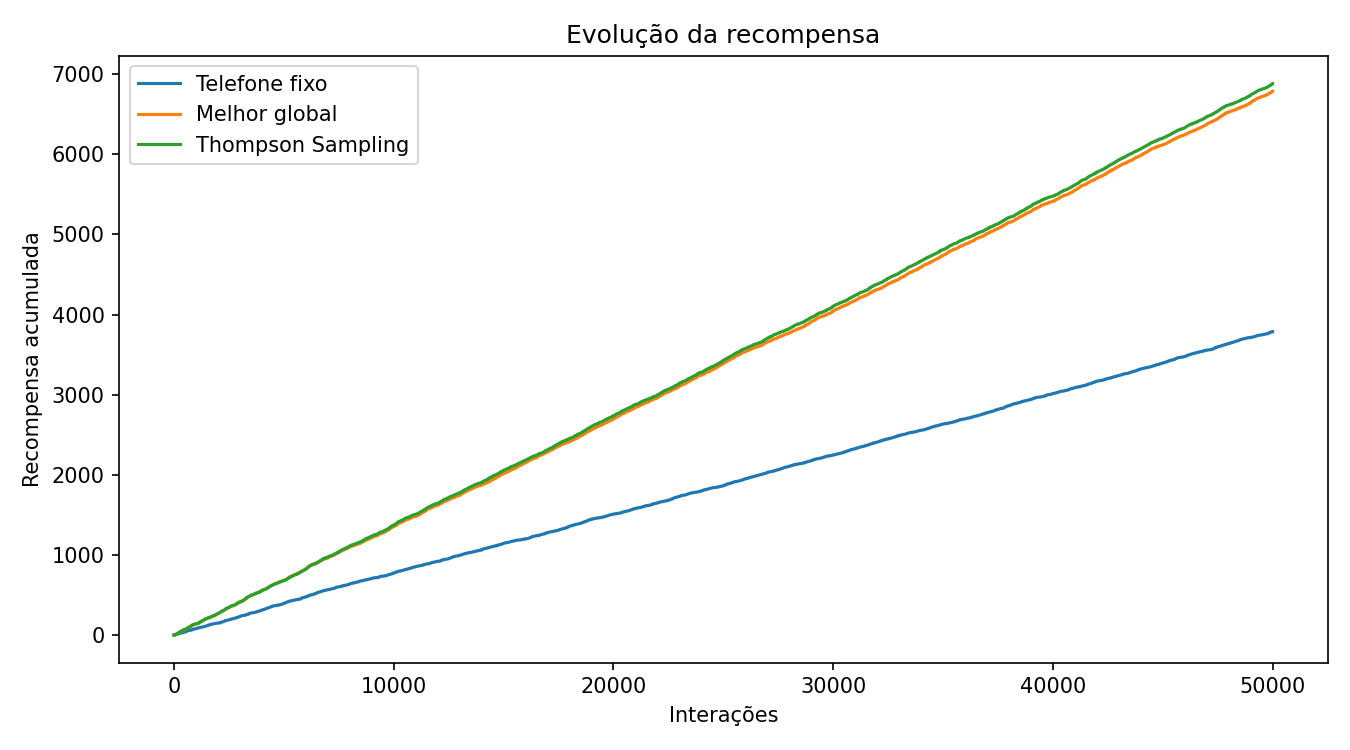

cumulative_regret.png


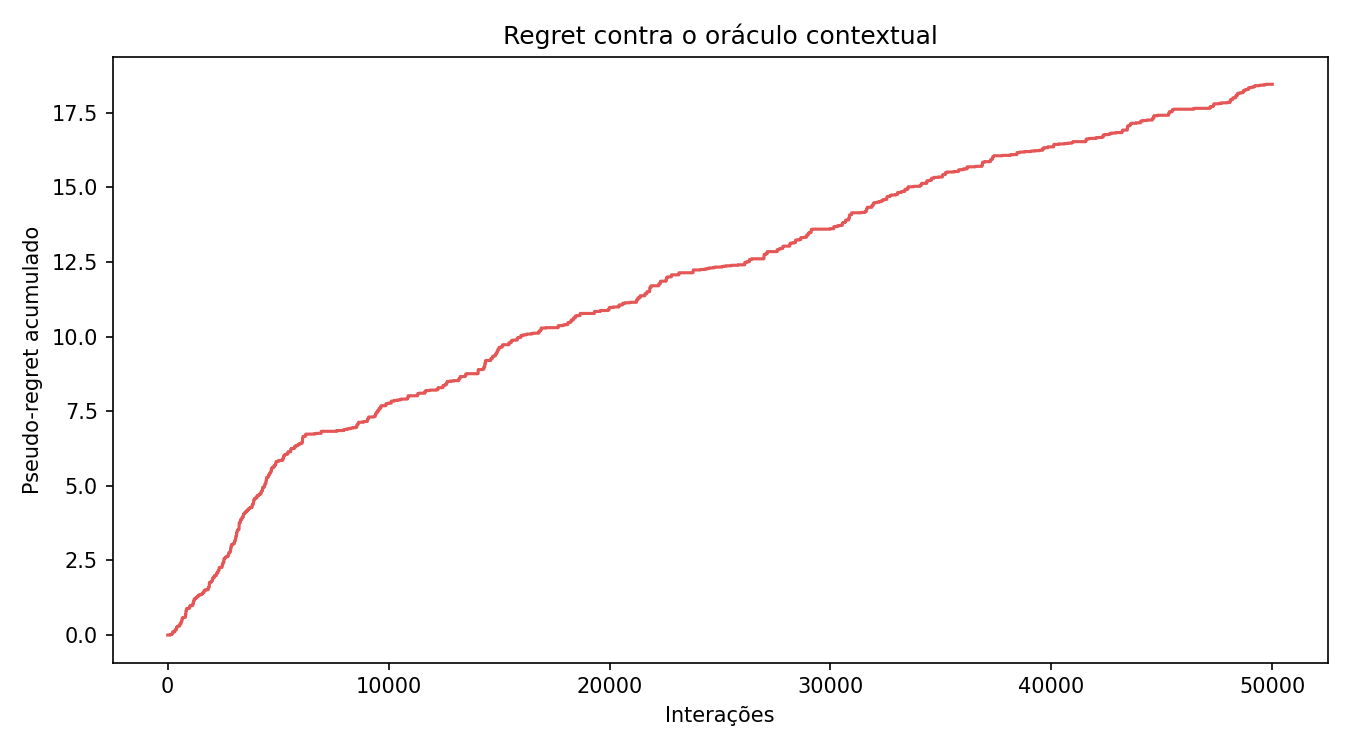

arm_selection_distribution.png


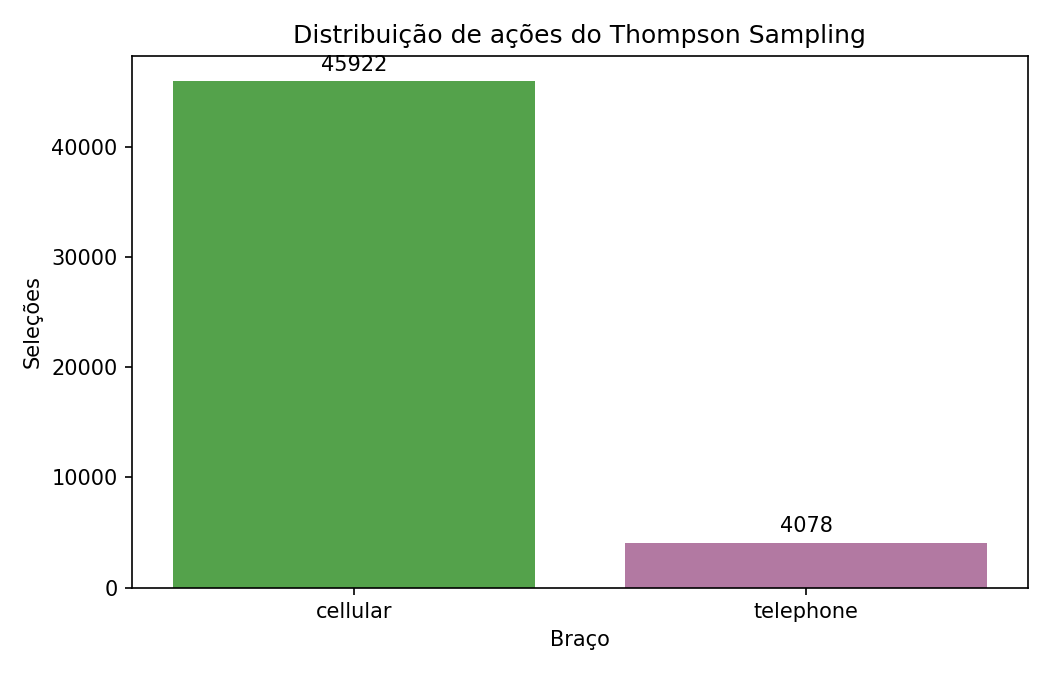

In [12]:
for filename in ["conversion_comparison.png", "cumulative_reward.png", "cumulative_regret.png", "arm_selection_distribution.png"]:
    print(filename)
    display(Image(filename=str(PROJECT_ROOT / "artifacts" / filename)))

## 17. Golden Set — exatamente 5 casos

In [13]:
golden = pd.read_csv(PROJECT_ROOT / "artifacts" / "golden_set.csv")
assert len(golden) == 5
display(golden)

,case_id,poutcome,previous,campaign,segment,recommended_action,estimated_conversion,alternative_action,alternative_estimated_conversion,rationale
0,GS-001,success,1,1,poutcome=success|previous=gt0|campaign=1-2,cellular,0.656136,telephone,0.587302,A recomendação está alinhada à maior taxa suav...
1,GS-002,failure,1,2,poutcome=failure|previous=gt0|campaign=1-2,telephone,0.159236,cellular,0.146410,A recomendação está alinhada à maior taxa suav...
2,GS-003,nonexistent,0,1,poutcome=nonexistent/other|previous=0|campaign...,cellular,0.124192,telephone,0.048270,A recomendação está alinhada à maior taxa suav...
3,GS-004,nonexistent,0,4,poutcome=nonexistent/other|previous=0|campaign=3+,cellular,0.095545,telephone,0.041727,A recomendação está alinhada à maior taxa suav...
4,GS-005,failure,0,3,poutcome=failure|previous=0|campaign=3+,cellular,0.145100,telephone,0.050974,Segmento sem histórico suficiente; recomendaçã...


## 18. Limitações e próximos passos

- O histórico registra apenas o braço escolhido; não há recompensa contrafactual observada.
- As probabilidades simuladas podem reproduzir viés de seleção e mudanças temporais do dataset.
- O serviço atual entrega um snapshot por maior média posterior; aprendizado online exige endpoint/evento de feedback, guardrails e auditoria.
- Antes de produção: experimento controlado, monitoramento de drift/conversão/distribuição de ações e análise de disparidades, com humano no loop para decisões sensíveis.